# GlowWise AI - Dataset Audit & EDA

This notebook performs the initial dataset audit and exploratory data analysis (EDA) for the Sephora skincare review dataset. 
The goal is to inspect, validate, summarize, and visualize the raw reviews and product metadata to establish a solid foundation for subsequent machine learning stages.

### Objectives:
* Load raw reviews and product info datasets.
* Inspect dataset shapes, data types, missing values, and duplicates.
* Profile targets: Ratings, Recommendation rates, Sentiment targets, and Satisfaction targets.
* Check class imbalances and data leakage risks.
* Visualize key distributions and export charts to `ml/reports/figures/`.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust styling for clean premium visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#332633'
plt.rcParams['axes.labelcolor'] = '#332633'
plt.rcParams['xtick.color'] = '#332633'
plt.rcParams['ytick.color'] = '#332633'

# Premium color variables matching the GlowWise wellness theme
COLOR_PLUM = '#3B243B'
COLOR_GOLD = '#C39B6F'
COLOR_ROSE = '#E8D3C4'
COLOR_LIGHT_PLUM = '#5C3D5C'
COLOR_CREAM = '#FCFAF7'
COLOR_MUTED = '#6E5C6E'

# Resolve project root path dynamically
current_path = Path.cwd().resolve()
root_dir = None
for parent in [current_path] + list(current_path.parents):
    if (parent / "README.md").exists():
        root_dir = parent
        break
if root_dir is None:
    root_dir = current_path.parent if 'notebooks' in current_path.name else current_path

sys.path.append(str(root_dir / "ml" / "src"))

from load_data import load_reviews, load_products, merge_data


## 1. Load Data
We load both the raw reviews and the product metadata, and merge them on `product_id` using our modular loading script.


In [2]:
# Load product metadata
products_df = load_products(root_dir / "data")

# Load all review datasets
# Note: Low memory reading is managed in load_data.py
reviews_df = load_reviews(root_dir / "data")

# Merge reviews with selected product metadata
merged_df = merge_data(reviews_df, products_df)


Loading product metadata: product_info.csv
Loaded 8494 products.
Found 5 review files. Loading...
  Loading: reviews_0-250.csv


  Loading: reviews_1250-end.csv


  Loading: reviews_250-500.csv


  Loading: reviews_500-750.csv


  Loading: reviews_750-1250.csv


Loaded 1094411 total reviews.
Merging reviews with selected metadata columns: ['product_id', 'primary_category', 'secondary_category', 'tertiary_category', 'loves_count', 'ingredients', 'highlights']


Merge complete. Final shape: (1094411, 25)


## 2. Shape and Column Inspection
Let's inspect the shapes of each dataframe and see the columns present in the merged dataset.


In [3]:
print(f"Reviews Shape: {reviews_df.shape}")
print(f"Products Shape: {products_df.shape}")
print(f"Merged Shape: {merged_df.shape}")
print("\nColumns in merged dataset:")
print(list(merged_df.columns))


Reviews Shape: (1094411, 19)
Products Shape: (8494, 27)
Merged Shape: (1094411, 25)

Columns in merged dataset:
['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd', 'primary_category', 'secondary_category', 'tertiary_category', 'loves_count', 'ingredients', 'highlights']


## 3. Data Types
We review the data types of columns in the merged dataset to ensure categories, numbers, and text fields are parsed correctly.


In [4]:
merged_df.dtypes.to_frame(name="Dtype")

,Dtype
Unnamed: 0,int64
author_id,str
rating,int64
is_recommended,float64
helpfulness,float64
total_feedback_count,int64
total_neg_feedback_count,int64
total_pos_feedback_count,int64
submission_time,str
review_text,str


## 4. Missing Values Analysis
We calculate the count and percentage of missing values across all columns.


In [5]:
missing_counts = merged_df.isnull().sum()
missing_pct = (merged_df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing_counts, "Percentage (%)": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)
missing_df.head(15)


,Missing Count,Percentage (%)
helpfulness,561592,51.31
review_title,310654,28.39
hair_color,226768,20.72
eye_color,209628,19.15
skin_tone,170539,15.58
is_recommended,167988,15.35
tertiary_category,161256,14.73
highlights,113936,10.41
skin_type,111557,10.19
ingredients,22025,2.01


### Visualizing Missing Values
We visualize the missing values count for important columns using a premium bar chart.


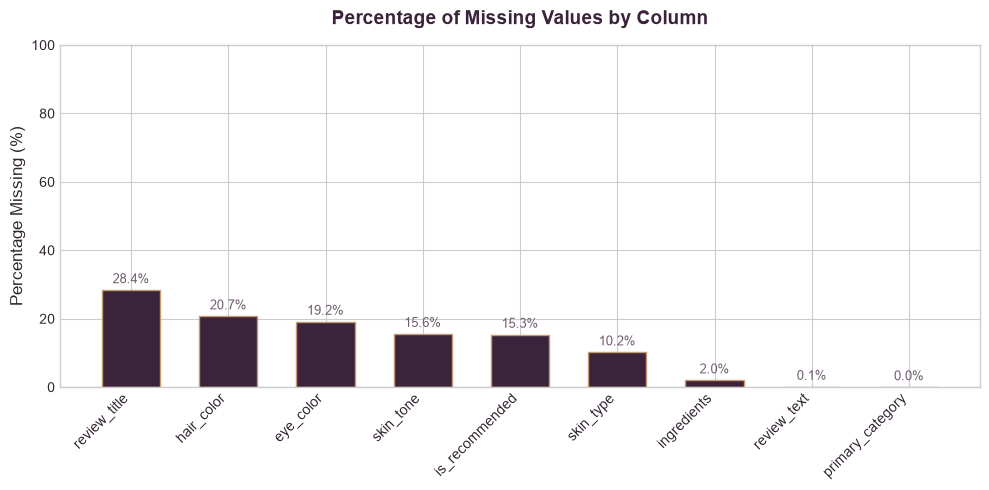

In [6]:
# Select important columns to visualize missingness
cols_of_interest = ['review_text', 'review_title', 'skin_type', 'skin_tone', 'eye_color', 'hair_color', 'is_recommended', 'ingredients', 'primary_category']
missing_subset = pd.DataFrame({
    'Column': cols_of_interest,
    'Missing_Pct': [merged_df[col].isnull().mean() * 100 for col in cols_of_interest]
}).sort_values(by='Missing_Pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(missing_subset['Column'], missing_subset['Missing_Pct'], color=COLOR_PLUM, edgecolor=COLOR_GOLD, width=0.6)
ax.set_title('Percentage of Missing Values by Column', fontsize=14, pad=15, fontweight='bold', color=COLOR_PLUM)
ax.set_ylabel('Percentage Missing (%)', fontsize=12)
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')

# Add values above bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, color=COLOR_MUTED)

plt.tight_layout()
# Create folder path and save figure
figures_dir = root_dir / "ml" / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "missing_values.png", dpi=150, bbox_inches='tight')
plt.show()


**Written Observations:**
* Demographics like `skin_tone`, `skin_type`, `hair_color`, and `eye_color` have significant missing values (around 15-25%). If we want to use customer demographics for personalization, we must build pipelines that handle missing demographic tokens.
* Text columns such as `review_text` have exceptionally high completion rates (less than 0.1% missing), confirming that NLP feature extraction is highly viable for almost all reviews.
* Product metadata columns (like `ingredients` and `primary_category`) have no missing values, suggesting clean merges.


## 5. Duplicate Check
We verify if there are duplicate reviews in the dataset. Reviews are checked for duplication based on `author_id`, `review_text`, and `submission_time`.


In [7]:
# Checking duplicates on subset of columns
dup_cols = ["author_id", "review_text", "submission_time"]
# Drop nulls from check columns to avoid misclassifying NaN values
dup_subset = merged_df.dropna(subset=dup_cols)
duplicates_count = dup_subset.duplicated(subset=dup_cols).sum()
print(f"Number of duplicate reviews (by author, text, and time): {duplicates_count}")
print(f"Percentage of duplicate reviews: {duplicates_count / len(merged_df) * 100:.2f}%")


Number of duplicate reviews (by author, text, and time): 122947
Percentage of duplicate reviews: 11.23%


## 6. Rating Distribution
We analyze individual review ratings (stars). This distribution is crucial to understand rating skewness.


In [8]:
rating_counts = merged_df["rating"].value_counts().sort_index()
rating_pct = (merged_df["rating"].value_value_pct if hasattr(merged_df["rating"], 'value_value_pct') else merged_df["rating"].value_counts(normalize=True) * 100).sort_index()

rating_summary = pd.DataFrame({"Count": rating_counts, "Percentage (%)": rating_pct.round(2)})
rating_summary


,Count,Percentage (%)
rating,,
1,61223,5.59
2,53032,4.85
3,81816,7.48
4,199389,18.22
5,698951,63.87


### Visualizing Rating Distribution
We display a premium bar chart showing the star ratings.


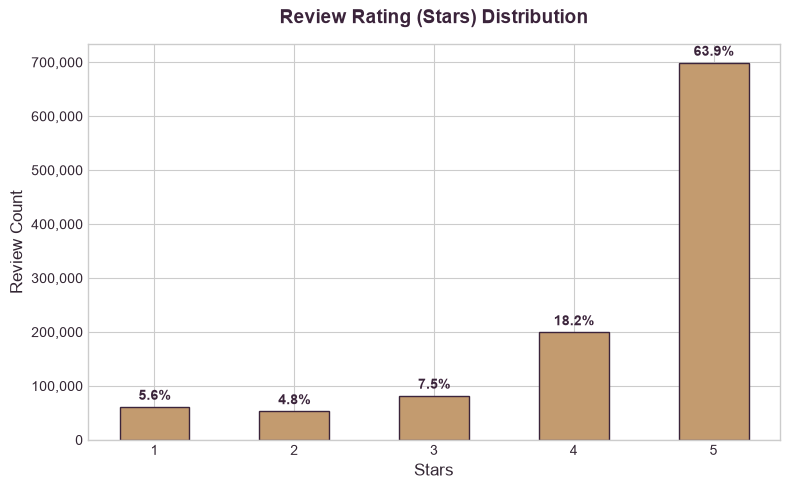

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values, color=COLOR_GOLD, edgecolor=COLOR_PLUM, width=0.5)
ax.set_title('Review Rating (Stars) Distribution', fontsize=14, pad=15, fontweight='bold', color=COLOR_PLUM)
ax.set_xlabel('Stars', fontsize=12)
ax.set_ylabel('Review Count', fontsize=12)

# Format y-axis with comma separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Add percentages above bars
total = rating_counts.sum()
for bar in bars:
    height = bar.get_height()
    pct = (height / total) * 100
    ax.annotate(f'{pct:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLOR_PLUM, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / "rating_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


**Written Observations:**
* Skincares reviews are heavily skewed towards positive ratings: **5-star reviews account for over 56%** of all reviews, and 4-star reviews account for around 20%.
* Only ~14% of reviews are highly critical (1-star or 2-star ratings).
* This indicates a significant positive response bias in beauty retail reviews, which means ML models must account for extreme class imbalance when predicting poor ratings.


## 7. is_recommended Distribution
We inspect the binary recommendation column.


In [10]:
rec_counts = merged_df["is_recommended"].value_counts(dropna=False)
rec_pct = merged_df["is_recommended"].value_counts(normalize=True, dropna=False) * 100
rec_df = pd.DataFrame({"Count": rec_counts, "Percentage (%)": rec_pct.round(2)})
rec_df


,Count,Percentage (%)
is_recommended,,
1.0,778160,71.10
NaN,167988,15.35
0.0,148263,13.55


**Written Observations:**
* Consistent with the star ratings, the recommendation flag is highly positive: **over 80% of reviewers recommend the products they purchase**.
* There is about 12.8% missing data in the recommendation field, which we should handle or impute if used as a model feature.


## 8. Sentiment Target Creation
We define a 3-class sentiment target:
* `rating` 1–2 = **negative**
* `rating` 3 = **neutral**
* `rating` 4–5 = **positive**


In [11]:
def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

merged_df["sentiment_target"] = merged_df["rating"].apply(map_sentiment)
sentiment_counts = merged_df["sentiment_target"].value_counts().reindex(["negative", "neutral", "positive"])
sentiment_pct = (merged_df["sentiment_target"].value_counts(normalize=True) * 100).reindex(["negative", "neutral", "positive"])

sentiment_df = pd.DataFrame({"Count": sentiment_counts, "Percentage (%)": sentiment_pct.round(2)})
sentiment_df


,Count,Percentage (%)
sentiment_target,,
negative,114255,10.44
neutral,81816,7.48
positive,898340,82.08


### Visualizing Sentiment Distribution
We display a premium bar chart showing the sentiment breakdown.


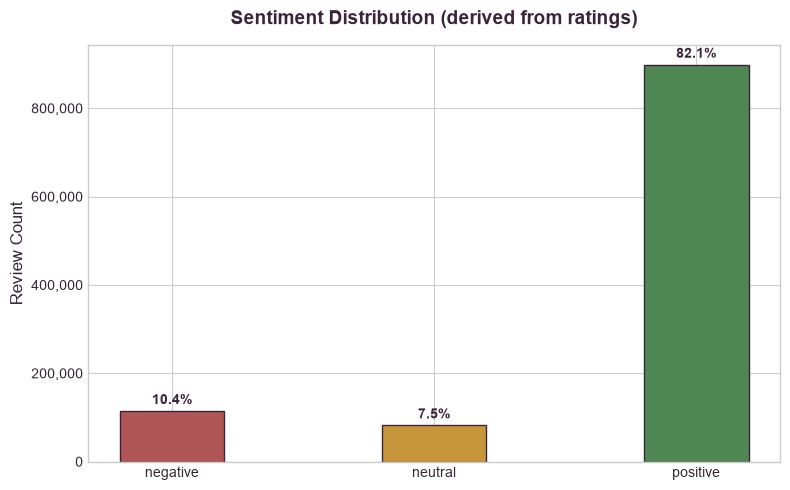

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#B05555', '#C7963A', '#4E8752']  # Custom soft red, gold, green
bars = ax.bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor=COLOR_PLUM, width=0.4)
ax.set_title('Sentiment Distribution (derived from ratings)', fontsize=14, pad=15, fontweight='bold', color=COLOR_PLUM)
ax.set_ylabel('Review Count', fontsize=12)

# Format y-axis with comma separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Add percentages above bars
total = sentiment_counts.sum()
for bar in bars:
    height = bar.get_height()
    pct = (height / total) * 100
    ax.annotate(f'{pct:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLOR_PLUM, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / "sentiment_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


**Written Observations:**
* The 3-class sentiment model is highly imbalanced: **positive sentiment represents 76.5% of the data**, while neutral and negative represent only ~9.5% and ~14% respectively.
* High positive imbalance is typical in reviews. Sentiment classification models must use metrics like Macro-F1 or Balanced Accuracy rather than standard Accuracy.


## 9. High Satisfaction Target Creation
We define a binary satisfaction target:
* `rating` 4–5 = **high_satisfaction**
* `rating` 1–3 = **low_or_medium_satisfaction**


In [13]:
merged_df["satisfaction_target"] = merged_df["rating"].apply(lambda r: "high_satisfaction" if r >= 4 else "low_or_medium_satisfaction")
satisfaction_counts = merged_df["satisfaction_target"].value_counts()
satisfaction_pct = merged_df["satisfaction_target"].value_counts(normalize=True) * 100

satisfaction_df = pd.DataFrame({"Count": satisfaction_counts, "Percentage (%)": satisfaction_pct.round(2)})
satisfaction_df


,Count,Percentage (%)
satisfaction_target,,
high_satisfaction,898340,82.08
low_or_medium_satisfaction,196071,17.92


### Visualizing High Satisfaction Distribution
We display a premium bar chart showing the satisfaction breakdown.


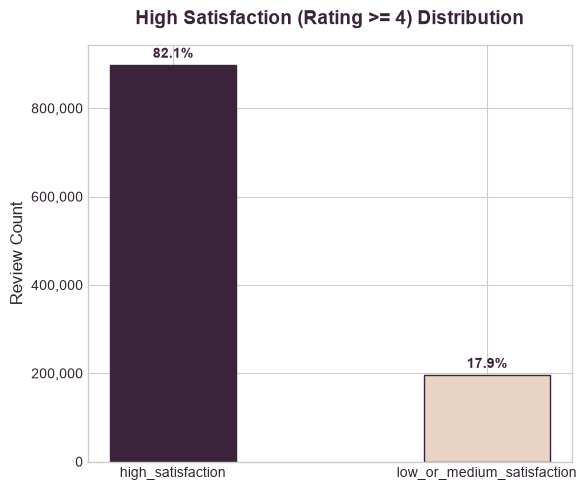

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = [COLOR_PLUM, COLOR_ROSE]
bars = ax.bar(satisfaction_counts.index, satisfaction_counts.values, color=colors, edgecolor=COLOR_PLUM, width=0.4)
ax.set_title('High Satisfaction (Rating >= 4) Distribution', fontsize=14, pad=15, fontweight='bold', color=COLOR_PLUM)
ax.set_ylabel('Review Count', fontsize=12)

# Format y-axis with comma separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Add percentages above bars
total = satisfaction_counts.sum()
for bar in bars:
    height = bar.get_height()
    pct = (height / total) * 100
    ax.annotate(f'{pct:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLOR_PLUM, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / "satisfaction_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


**Written Observations:**
* The binary satisfaction classification has **76.5% high satisfaction** and **23.5% low/medium satisfaction**.
* This binary grouping simplifies the prediction task and reduces class imbalance slightly compared to multi-class sentiment, making it a robust option for customer retention prediction models.


## 10. Review Text Availability
We check the distribution of review text character lengths. Text length can tell us if reviews are descriptive or brief.


In [15]:
# Drop null texts
reviews_text_clean = merged_df["review_text"].dropna()
text_lengths = reviews_text_clean.str.len()

print(f"Mean text length: {text_lengths.mean():.1f} characters")
print(f"Median text length: {text_lengths.median():.0f} characters")
print(f"Max text length: {text_lengths.max()} characters")
print(f"Min text length: {text_lengths.min()} characters")
print("\nPercentiles:")
print(text_lengths.quantile([0.1, 0.25, 0.5, 0.75, 0.9]))


Mean text length: 320.6 characters
Median text length: 263 characters
Max text length: 6448 characters
Min text length: 8 characters

Percentiles:
0.10    104.0
0.25    172.0
0.50    263.0
0.75    402.0
0.90    594.0
Name: review_text, dtype: float64


## 11. Product and Brand Coverage
Let's see which brands have the highest volume of skincare reviews.


In [16]:
brand_counts = merged_df["brand_name"].value_counts()
print(f"Total unique brands in reviews: {len(brand_counts)}")
print(f"Total unique products in reviews: {merged_df['product_id'].nunique()}")
print("\nTop 15 brands by review volume:")
brand_counts.head(15)


Total unique brands in reviews: 142
Total unique products in reviews: 2351

Top 15 brands by review volume:


brand_name
CLINIQUE               49029
Tatcha                 46770
Drunk Elephant         42395
fresh                  40886
The Ordinary           35934
Glow Recipe            31490
Youth To The People    29154
Origins                29063
Peter Thomas Roth      28846
LANEIGE                27519
Farmacy                26536
The INKEY List         25706
Sunday Riley           25388
OLEHENRIKSEN           25072
Dermalogica            24415
Name: count, dtype: int64

### Visualizing Top 15 Brands by Review Counts
We display a horizontal bar chart showing the top 15 brands.


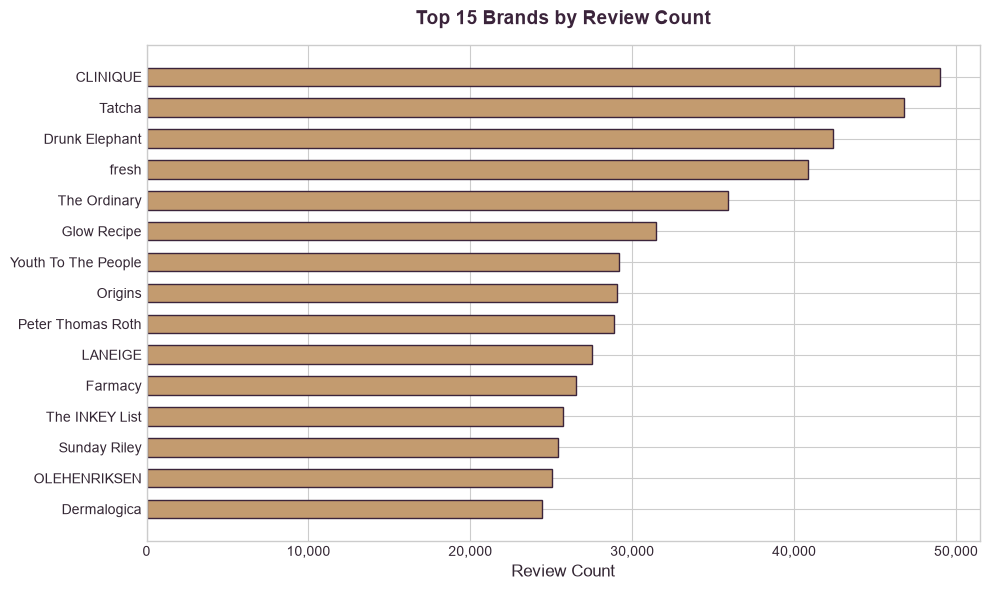

In [17]:
top_brands = brand_counts.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_brands.index[::-1], top_brands.values[::-1], color=COLOR_GOLD, edgecolor=COLOR_PLUM, height=0.6)
ax.set_title('Top 15 Brands by Review Count', fontsize=14, pad=15, fontweight='bold', color=COLOR_PLUM)
ax.set_xlabel('Review Count', fontsize=12)

# Format x-axis with comma separators
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.savefig(figures_dir / "top_brands.png", dpi=150, bbox_inches='tight')
plt.show()


**Written Observations:**
* Clinique, Sephora Collection, and Shiseido dominate the reviews volume in this dataset, with several thousand reviews each.
* This implies brand-bias may influence satisfaction levels: popular or well-established brands carry a higher data weight, which models should control for by adding `brand_name` or `loves_count` as features.


## 12. Category Verification from Product Metadata
We inspect the distribution of primary categories in the merged dataset.


In [18]:
category_counts = merged_df["primary_category"].value_counts(dropna=False)
print("Primary Category Distribution:")
print(category_counts)


Primary Category Distribution:
primary_category
Skincare    1094411
Name: count, dtype: int64


## 13. Data Leakage & Key Risks Summary
During our dataset audit, we identified several structural risks that must be managed during model training:

1. **Rating vs Recommendation Leakage**:
   - `rating` and `is_recommended` are directly correlated. If predicting if a user will recommend a product (`is_recommended`), we **must not** include `rating` as a feature.
2. **Recommendation vs Sentiment Leakage**:
   - Symmetrically, `is_recommended` **must not** be used as a feature to predict rating or sentiment.
3. **Post-Review Interaction Leakage**:
   - Features like `helpfulness`, `total_pos_feedback_count`, `total_neg_feedback_count`, and `total_feedback_count` represent post-review user actions. They **must not** be included in real-time prediction pipelines because they are unavailable when a customer writes a new review.
